**Bibliotecas a serem importadas**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Importar módulo de regressão linear da biblioteca scikit learn
from sklearn.linear_model import LinearRegression

# Superfície de erro
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [2]:
seed = 42
np.random.seed(seed)

**FUNÇÕES PARA PLOTAR FUNÇÕES OBJETIVO E OBSERVÁVEL (RETA)**

Ela gera um gráfico 2D que mostra três coisas:

A função objetivo (y), que representa a relação teórica entre x e y.

Os dados observáveis com ruído (y_noisy), que simulam valores reais.

A predição do modelo (y_pred), obtida por regressão linear.


In [3]:
# Ela é usada quando há apenas um atributo (variável x), ou seja, o caso de uma regressão linear simples.
# EXEMPLO: y = a0 + a1x

def plot_objetivo_observavel_pred_2D (x, y, y_noisy, y_pred):
  fig = plt.figure()
  plt.plot(x, y, label = "Função Objetivo", linewidth = 7)
  plt.plot(x, y_noisy, '.', label = "Função Observável (Versão Ruidosa)")
  plt.plot(x, y_pred, 'r.', label='Predição via Equação Normal (Numpy)', linewidth=4)
  plt.xlabel("", fontsize = 14)
  plt.ylabel("", fontsize = 14)
  plt.legend()
  plt.grid()
  plt.show()

**IMPLEMENTAÇÃO DA EQUAÇÃO NORMAL COM PESO DE INTERCEPT E SEM PESO DE INTERCEPT**

Essa função calcula os coeficientes da regressão linear usando a Equação Normal e leva em consideração o termo de intercepto (também chamado de bias)

Ela ajusta um modelo da forma: $$
y = a_0  +a_1 x
$$

$$a0$$ → Intercepto (termo independente).


$$a1​$$

  → Coeficiente angular (pendente da reta).

In [4]:
# EXEMPLO: y = a0+a1x
def eq_normal_with_intercept(x, y, y_noisy):
  # inicializa arrays vazios, usadas para armazenar os dados e resultados
  X = np.array([])
  a_numpy = np.array([])
  Je_optimum = np.array([])

  # Cria uma coluna de 1's com N linhas (intercepto a0).
  # Concatena essa coluna com x, formando a matriz de design X.
  X = np.c_[np.ones((N,1)),x]

  # calcula os coeficientes a0 e a1 usando a Equação Normal, o resultado é um vetor a com dois valores: a[0] > intercepto ao, e a[1] > inclinação a1.
  a_numpy = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)


  # Calcula as Predições do Modelo
  y_pred = X.dot(a_numpy) #Multiplica a matriz de entrada pelos coeficientes encontrados.


  # Calcula o Erro Quadrático Médio Je, indica o quão bem o modelo se ajusta aos dados.
  Je_optimum = (1/len(y))*np.sum(np.power((y_noisy-y_pred),2))


  # Retorna os resultados
  # a_numpy: Vetor com a0 e a1
  # y_pred: Predições paracada x
  # Je_optimum: Erro quadrático médio
  return a_numpy, y_pred, Je_optimum # Para printar: print("a_0 = %1.4f" % a_numpy[0,0]), print("a_1 = %1.4f" % a_numpy[1,0])


In [5]:
# EXEMPLO: y = a1x
def eq_normal_without_intercept(x, y, y_noisy):
  X = np.array([])
  a_numpy = np.array([])
  Je_optimum = np.array([])
  X = np.c_[x]
  a_numpy = np.linalg.pinv(np.transpose(X).dot(X)).dot(np.transpose(X)).dot(y_noisy)

  y_pred = X.dot(a_numpy)

  Je_optimum = (1/len(y))*np.sum(np.power((y_noisy-y_pred),2))

  return a_numpy, y_pred, Je_optimum # Para printar: print("a_1 = %1.4f" % a_numpy[0,0]), uma vez que se tem apenas um valor de peso/parâmetro


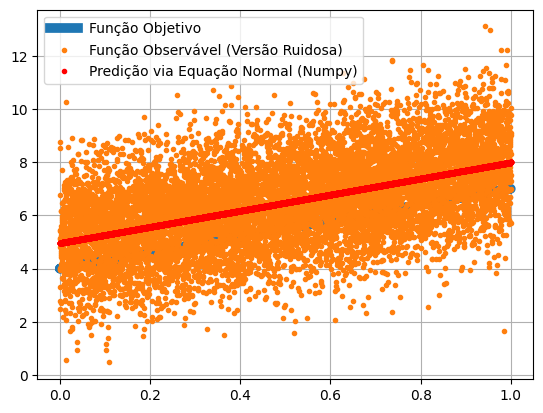

MSE = 2.022048


In [8]:
N = 10000
x = np.random.rand(N,1)

# Função objetivo, 4-> intercepto (a0) e 3 -> inclinação (a1)
y = 4+3*x
w = np.random.randn(N,1)*np.sqrt(2) + 1
y_noisy = y + w


a_numpy, y_pred, Je_optimum = eq_normal_with_intercept(x, y, y_noisy)
plot_objetivo_observavel_pred_2D(x, y, y_noisy, y_pred)

print("MSE = %1.6f" % Je_optimum)

**RESPOSTAS SOBRE A EQUAÇÃO NORMAL**

1.Aumentem o número de exemplos, N, alterem o valor da variância do ruído adicionado às amostras da função objetivo para 2 e verifiquem o valor do MSE. O MSE é igual à variância? Justifique sua resposta.

R: O MSE tende à variância do ruído adicionado às amostras mesmo quando alteramos sua variância. À medida que se aumenta o valor de
, a precisão aumenta.

2.Aumentem o número de exemplos, N, façam com que o ruído tenha média igual a 1, alterem o valor da variância do ruído adicionado às amostras da função objetivo para 2 e verifiquem o valor do MSE. O MSE é igual à variância? Justifique sua resposta.

R: Quando se adiciona uma unidade à média do ruído que contamina as amostras, a função observável desloca-se uma unidade para cima e, consequentemente, as predições via equação normal acompanharão essa versão ruidosa. Isso representa um sobreajuste? Uma vez que minhas predições acompanham a versão ruidosa, ao invés de se ajustar à função objetivo, que se manteve a mesma do caso anterior?

O MSE tende à variância do ruído, especialmente, quando se aumenta o número de amostras.

3.Usando o conjunto de treinamento gerado no item 2, onde o ruído tem média igual a 1, encontre uma função hipótese (você pode usar a biblioteca numpy ou a scikit-learn para encontrar os pesos) que aproxime esses dados e na sequência cria uma figura comparando os dados ruidosos, a função objetivo e a função hipótese encontrada. A função hipótese aproxima a função objetivo? Justifique sua resposta.

R: A função hipótese não aproxima a função objetivo, pois o ruído fez com que houvesse um deslocamento na versão ruidosa, quando comparada com a função objetivo. A média inserida no ruído interferiu diretamente no peso de intercept da função objetivo.